# Las losowy

## Zadanie na 3

Implementacja lasu losowego

#### Import bibliotek

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
import time

#### Funkcje do oceny skuteczności 

In [3]:
def plot_confusion_matrix(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Macierz Pomyłek")
    plt.show()

def calculate_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    return accuracy, sensitivity, specificity

def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Losowa klasyfikacja')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Krzywa ROC')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

### Wygenerowanie danych

Jednomodowe - make_classification

In [4]:
my_index = 259199
my_n_samples = int(str(my_index)[0]+ str(my_index)[1] + str(my_index)[-2] + str(my_index)[-1])
X_classification, y_classification = make_classification(
    n_samples=my_n_samples, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_clusters_per_class=1, 
    random_state=my_index,
)

print('x', X_classification.shape)
print('y', y_classification.shape)

x (2599, 2)
y (2599,)


Jednomodowe - make_moons

In [5]:
X_moons, y_moons = make_moons(n_samples=my_n_samples, noise=0.2, random_state=my_index)

print('X_moons', X_moons.shape)
print('y_moons', y_moons.shape)

X_moons (2599, 2)
y_moons (2599,)


Wielomodowy - make_blobs

In [6]:
n_features = 2    
n_classes = 2     
n_clusters_per_class = 2

X_blobs, y_blobs = make_blobs(
    n_samples=my_n_samples,
    centers=n_classes * n_clusters_per_class,
    n_features=n_features,
    random_state=my_index
)

y_blobs = y_blobs % n_classes

#### Podział danych na treningowe i testowe

In [7]:
X_classification_train, X_classification_test, y_classification_train, y_classification_test = train_test_split(
    X_classification, y_classification, test_size=0.2, random_state=my_index
)

X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=my_index
)

X_blobs_train, X_blobs_test, y_blobs_train, y_blobs_test = train_test_split(
    X_blobs, y_blobs, test_size=0.2, random_state=my_index
)

print("classification:", X_classification_train.shape, y_classification_train.shape, X_classification_test.shape, y_classification_test.shape)
print("nmoons:", X_moons_train.shape, y_moons_train.shape, X_moons_test.shape, y_moons_test.shape)
print("blobs:", X_blobs_train.shape, y_blobs_train.shape, X_blobs_test.shape, y_blobs_test.shape)


classification: (2079, 2) (2079,) (520, 2) (520,)
nmoons: (2079, 2) (2079,) (520, 2) (520,)
blobs: (2079, 2) (2079,) (520, 2) (520,)


### Własna implementacja

In [8]:
class DecisionTree:
    class TreeNode:
        def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value

    def __init__(self, max_depth=None, n_features=None, criterion='gini'):
        self.max_depth = max_depth
        self.n_features = n_features
        self.criterion = criterion
        self.root = None

    def _gini(self, y):
        counts = np.bincount(y)
        probs = counts / len(y)
        return 1.0 - np.sum(probs ** 2)

    def _entropy(self, y):
        counts = np.bincount(y)
        probs = counts / len(y)
        probs = probs[probs > 0]
        return -np.sum(probs * np.log2(probs))

    def _impurity(self, y):
        return self._gini(y) if self.criterion == 'gini' else self._entropy(y)

    def fit(self, X, y):
        def build(X, y, depth):
            if len(set(y)) == 1 or len(y) == 0 or (self.max_depth and depth >= self.max_depth):
                majority = Counter(y).most_common(1)[0][0]
                return self.TreeNode(value=majority)

            best_gain = -1
            best_feature = None
            best_threshold = None

            feat_idxs = np.random.choice(X.shape[1], self.n_features, replace=False)

            for i in feat_idxs:
                values = X[:, i]
                thresholds = np.unique(np.percentile(values, np.arange(10, 100, 10)))
                for t in thresholds:
                    left = y[values <= t]
                    right = y[values > t]
                    if len(left) == 0 or len(right) == 0:
                        continue
                    gain = self._impurity(y) - (len(left)/len(y))*self._impurity(left) - (len(right)/len(y))*self._impurity(right)
                    if gain > best_gain:
                        best_gain = gain
                        best_feature = i
                        best_threshold = t

            if best_feature is None:
                return self.TreeNode(value=Counter(y).most_common(1)[0][0])

            left_mask = X[:, best_feature] <= best_threshold
            left = build(X[left_mask], y[left_mask], depth+1)
            right = build(X[~left_mask], y[~left_mask], depth+1)
            return self.TreeNode(best_feature, best_threshold, left, right)

        self.root = build(X, y, 0)

    def predict(self, X):
        def traverse(x, node):
            while node.value is None:
                node = node.left if x[node.feature] <= node.threshold else node.right
            return node.value

        return np.array([traverse(row, self.root) for row in X])


class RandomForest:
    def __init__(self, n_estimators=10, max_depth=None, max_features='sqrt', criterion='gini'):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.criterion = criterion
        self.trees = []
        self.bootstraps = []

    def _get_n_features(self, n_total):
        if self.max_features == 'sqrt':
            return int(np.sqrt(n_total))
        elif isinstance(self.max_features, int):
            return self.max_features
        else:
            return n_total

    def fit(self, X, y):
        self.trees = []
        self.bootstraps = []
        n_total_features = X.shape[1]
        n_feats = self._get_n_features(n_total_features)

        for _ in range(self.n_estimators):
            idxs = np.random.choice(len(X), len(X), replace=True)
            X_sample, y_sample = X[idxs], y[idxs]
            tree = DecisionTree(max_depth=self.max_depth, n_features=n_feats, criterion=self.criterion)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            self.bootstraps.append(set(idxs)) 

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        return np.apply_along_axis(lambda x: Counter(x).most_common(1)[0][0], axis=0, arr=tree_preds)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

    def oob_score(self, X, y):
        n_samples = len(X)
        votes = [list() for _ in range(n_samples)]

        for tree, boot_idx in zip(self.trees, self.bootstraps):
            oob_idxs = [i for i in range(n_samples) if i not in boot_idx]
            if not oob_idxs:
                continue
            preds = tree.predict(X[oob_idxs])
            for i, pred in zip(oob_idxs, preds):
                votes[i].append(pred)

        final_preds = []
        valid_y = []
        for i, preds in enumerate(votes):
            if preds:
                majority_vote = Counter(preds).most_common(1)[0][0]
                final_preds.append(majority_vote)
                valid_y.append(y[i])
        return np.mean(np.array(final_preds) == np.array(valid_y))


#### Porównanie wyników 

Własna implementacja

classification (custom RF)
Accuracy: 0.93, Sensitivity: 0.90, Specificity: 0.96


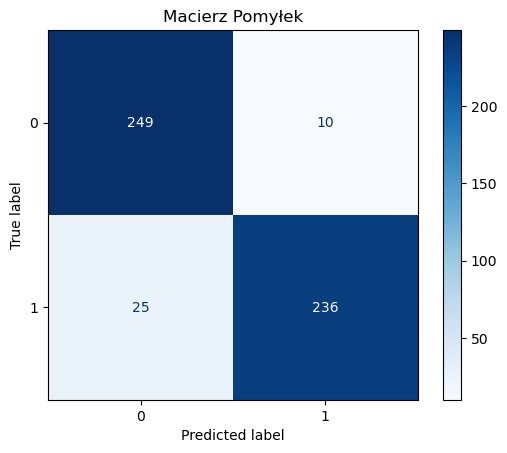

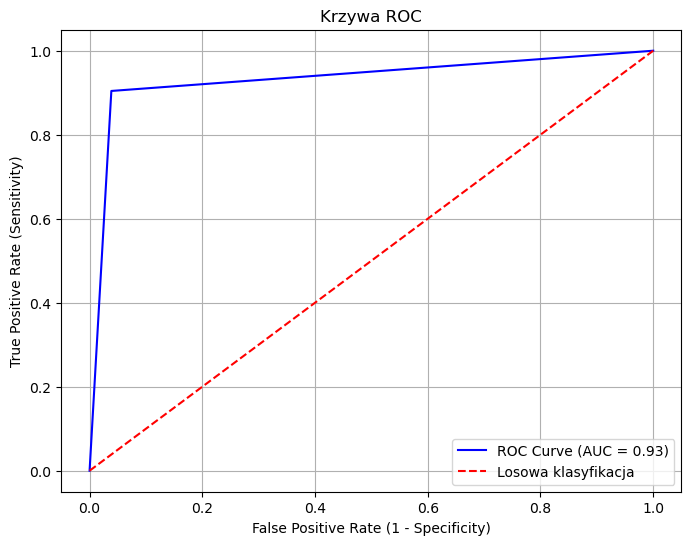

KeyboardInterrupt: 

In [9]:
results = pd.DataFrame(columns=["Accuracy", "Sensitivity", "Specificity"])

rf_classification = RandomForest(n_estimators=100, max_depth=None)
rf_classification.fit(X_classification_train, y_classification_train)
y_pred_classification = rf_classification.predict(X_classification_test)

print("classification (custom RF)")
accuracy, sensitivity, specificity = calculate_metrics(y_classification_test, y_pred_classification)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["custom RF - classification"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_classification_test, y_pred_classification)
plot_roc_curve(y_classification_test, y_pred_classification)

rf_moons = RandomForest(n_estimators=100, max_depth=None)
rf_moons.fit(X_moons_train, y_moons_train)
y_pred_moons = rf_moons.predict(X_moons_test)

print("moons (custom RF)")
accuracy, sensitivity, specificity = calculate_metrics(y_moons_test, y_pred_moons)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["custom RF - moons"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_moons_test, y_pred_moons)
plot_roc_curve(y_moons_test, y_pred_moons)

rf_blobs = RandomForest(n_estimators=100, max_depth=None)
rf_blobs.fit(X_blobs_train, y_blobs_train)
y_pred_blobs = rf_blobs.predict(X_blobs_test)

print("blobs (custom RF)")
accuracy, sensitivity, specificity = calculate_metrics(y_blobs_test, y_pred_blobs)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["custom RF - blobs"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_blobs_test, y_pred_blobs)
plot_roc_curve(y_blobs_test, y_pred_blobs)

RandomForestClassifier

classification
Accuracy: 0.93, Sensitivity: 0.91, Specificity: 0.95


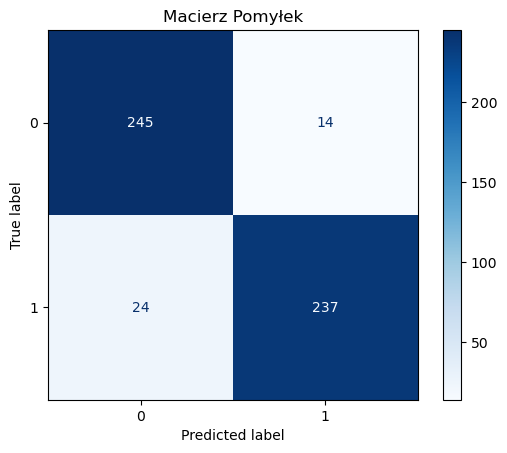

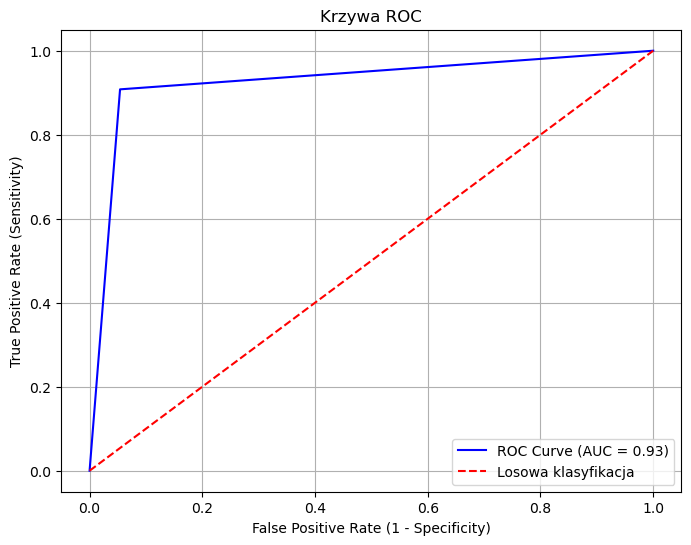

moons
Accuracy: 0.98, Sensitivity: 0.98, Specificity: 0.98


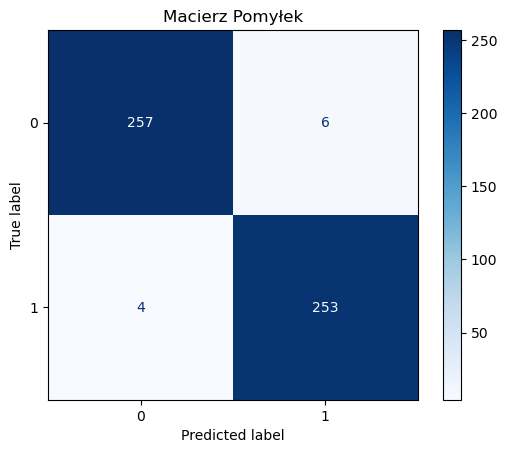

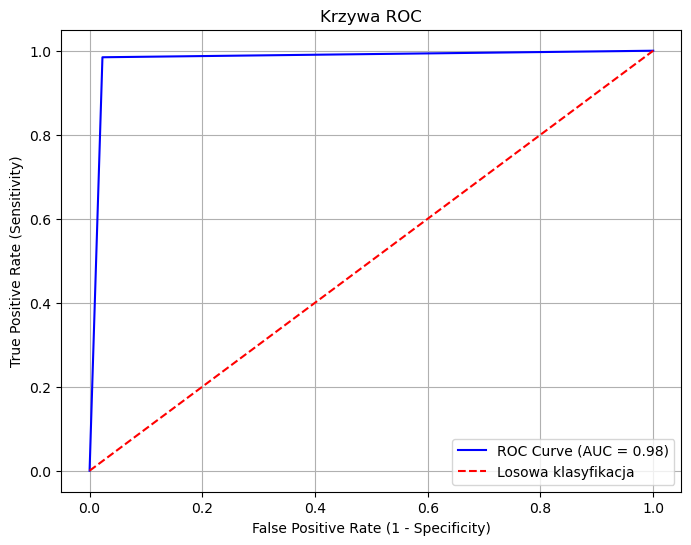

blobs
Accuracy: 0.88, Sensitivity: 0.88, Specificity: 0.89


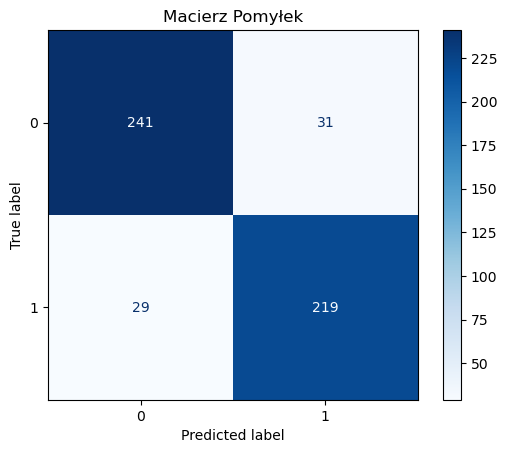

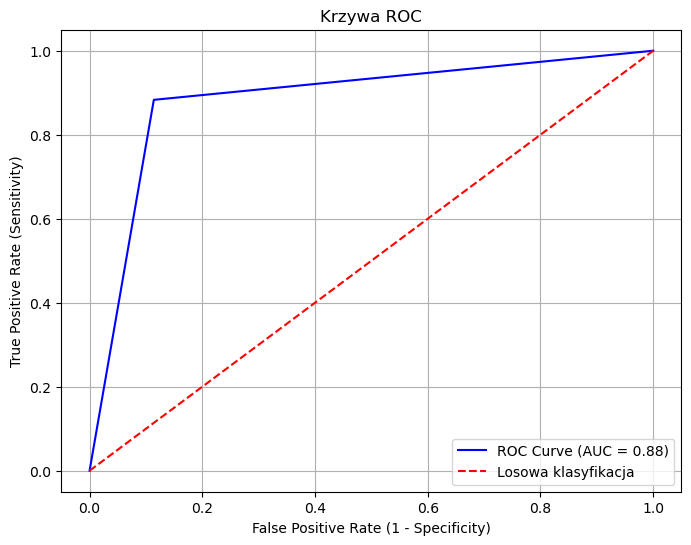

In [ ]:
clf_classification = RandomForestClassifier(random_state=my_index)
clf_classification.fit(X_classification_train, y_classification_train)
y_pred_classification = clf_classification.predict(X_classification_test)

print("classification")
accuracy, sensitivity, specificity = calculate_metrics(y_classification_test, y_pred_classification)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["sklearn RF - classification"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_classification_test, y_pred_classification)
plot_roc_curve(y_classification_test, y_pred_classification)

clf_moons = RandomForestClassifier(random_state=my_index)
clf_moons.fit(X_moons_train, y_moons_train)
y_pred_moons = clf_moons.predict(X_moons_test)

print("moons")
accuracy, sensitivity, specificity = calculate_metrics(y_moons_test, y_pred_moons)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["sklearn RF - moons"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_moons_test, y_pred_moons)
plot_roc_curve(y_moons_test, y_pred_moons)

clf_blobs = RandomForestClassifier(random_state=my_index)
clf_blobs.fit(X_blobs_train, y_blobs_train)
y_pred_blobs = clf_blobs.predict(X_blobs_test)

print("blobs")
accuracy, sensitivity, specificity = calculate_metrics(y_blobs_test, y_pred_blobs)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["sklearn RF - blobs"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_blobs_test, y_pred_blobs)
plot_roc_curve(y_blobs_test, y_pred_blobs)

In [ ]:
pd.DataFrame(results)

,Accuracy,Sensitivity,Specificity
custom RF - classification,0.923077,0.900383,0.945946
custom RF - moons,0.980769,0.984436,0.977186
custom RF - blobs,0.894231,0.887097,0.900735
sklearn RF - classification,0.926923,0.908046,0.945946
sklearn RF - moons,0.980769,0.984436,0.977186
sklearn RF - blobs,0.884615,0.883065,0.886029


## Zadanie na 4

Analiza zbioru NASA JPL Asteroid w oparciu o las losowy

#### Wczytanie danych 

In [13]:
file_path = f'./Datasets/NASA_JPL_asteroid.csv'
data = pd.read_csv(file_path, low_memory=False)

print(data.shape)
data.head()

(958524, 45)


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


#### Sprawdzenie ilości brakujących wartości

In [14]:
missing_counts = data.isnull().sum()
missing_percent = 100 * missing_counts / len(data)
missing_table = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent': missing_percent
})
missing_table = missing_table[missing_table['Missing Count'] > 0].sort_values(by='Missing Percent', ascending=False)
print('do usunięcia:', missing_table[missing_table['Missing Percent'] > 80].index.tolist())
missing_table

do usunięcia: ['prefix', 'name', 'albedo', 'diameter_sigma', 'diameter']


,Missing Count,Missing Percent
prefix,958506,99.998122
name,936460,97.698128
albedo,823421,85.905100
diameter_sigma,822443,85.803068
diameter,822315,85.789714
sigma_per,19926,2.078821
sigma_ad,19926,2.078821
sigma_i,19922,2.078404
sigma_q,19922,2.078404
sigma_a,19922,2.078404


Znalezienie kolumny z nieunikalnymi wartościami

In [29]:
unique_counts = data.nunique()
unique_counts = unique_counts[unique_counts < 2]
print(unique_counts)

unique_columns = unique_counts.index.tolist()
print("Columns with only one unique value:", unique_columns)

equinox    1
dtype: int64
Columns with only one unique value: ['equinox']


#### Usunięcie kolumn 

z polecenia Orbit_id i full_name

również tych gdzie % brakujących wartości przekracza 80%

In [ ]:
print(data.columns)

columns_to_drop = set(['id', 'full_name', 'orbit_id'] + missing_table[missing_table['Missing Percent'] > 80].index.tolist() + unique_columns) 
data = data.drop(columns=columns_to_drop)

data.head()

Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H',
       'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'rms'],
      dtype='object')


,spkid,pdes,neo,pha,H,epoch,epoch_mjd,epoch_cal,equinox,e,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,2000001,1,N,N,3.40,2458600.5,58600,20190427.0,J2000,0.076009,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,2000002,2,N,N,4.20,2459000.5,59000,20200531.0,J2000,0.229972,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,2000003,3,N,N,5.33,2459000.5,59000,20200531.0,J2000,0.256936,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,2000004,4,N,N,3.00,2458600.5,58600,20190427.0,J2000,0.088721,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,2000005,5,N,N,6.90,2459000.5,59000,20200531.0,J2000,0.190913,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


#### Usunięcie wierszy z brakującymi wartościami w 'neo' lub 'pha'


In [16]:
data = data.dropna(subset=['neo', 'pha'])

data = data.reset_index(drop=True)
print(data.shape)

(938599, 37)


#### Podział na x i y 

In [17]:
X = data.drop(columns=['pha', 'neo'])

y_neo = data['neo']
y_neo = (y_neo == 'Y').astype(int)

y_pha = data['pha']
y_pha = (y_pha == 'Y').astype(int)

print(X.shape, y_pha.shape, y_neo.shape)

(938599, 35) (938599,) (938599,)


Wylistowanie kolumn kategorycznych i numerycznych 

In [18]:
categorical_columns = X.select_dtypes(include=['object']).columns
print('Categorical columns:', categorical_columns, categorical_columns.shape)

numerical_columns = X.select_dtypes(include=['float64', 'int64']).columns
print('Numerical columns:', numerical_columns, numerical_columns.shape)

Categorical columns: Index(['pdes', 'equinox', 'class'], dtype='object') (3,)
Numerical columns: Index(['spkid', 'H', 'epoch', 'epoch_mjd', 'epoch_cal', 'e', 'a', 'q', 'i',
       'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid',
       'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om',
       'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per',
       'rms'],
      dtype='object') (32,)


#### Imputacja brakujących wartości

In [19]:
missing_values_before = X.isnull().sum()
missing_values_before = missing_values_before[missing_values_before > 0]

for col in categorical_columns:
    mode_value = X[col].mode()[0]
    X[col].fillna(mode_value, inplace=True)

for col in numerical_columns:
    median_value = X[col].median()
    X[col].fillna(median_value, inplace=True)

missing_values_after = X.isnull().sum()

comparison_table = pd.DataFrame({
    'Column': missing_values_before.index,
    'Missing Before': missing_values_before.values,
    'Missing After': missing_values_after[missing_values_before.index].values
})

print(comparison_table)

       Column  Missing Before  Missing After
0           H            6262              0
1          ma               1              0
2     sigma_e               1              0
3     sigma_a               1              0
4     sigma_q               1              0
5     sigma_i               1              0
6    sigma_om               1              0
7     sigma_w               1              0
8    sigma_ma               1              0
9    sigma_ad               1              0
10    sigma_n               1              0
11   sigma_tp               1              0
12  sigma_per               1              0
13        rms               1              0


In [32]:
for col in categorical_columns:
    X[col] = X[col].astype('category').cat.codes


preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), numerical_columns),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
])

preprocessor.fit_transform(X)

X.head()

,spkid,pdes,H,epoch,epoch_mjd,epoch_cal,equinox,e,a,q,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,2000001,0,3.40,2458600.5,58600,20190427.0,0,0.076009,2.769165,2.558684,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,7,0.43301
1,2000002,113574,4.20,2459000.5,59000,20200531.0,0,0.229972,2.773841,2.135935,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,7,0.35936
2,2000003,615679,5.33,2459000.5,59000,20200531.0,0,0.256936,2.668285,1.982706,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,7,0.33848
3,2000004,726790,3.00,2458600.5,58600,20190427.0,0,0.088721,2.361418,2.151909,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,7,0.39980
4,2000005,837905,6.90,2459000.5,59000,20200531.0,0,0.190913,2.574037,2.082619,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,7,0.52191


### NEO

#### Próbkowanie

In [ ]:
neo_data = X
neo_data['neo'] = y_neo

neo_data = neo_data.sample(frac=0.1, random_state=my_index)

X_neo = neo_data.drop(columns=['neo'])
y_neo_new = neo_data['neo']

#### Podział danych na treningowe i testowe dla neo

In [ ]:
X_neo_train, X_neo_test, y_neo_train, y_neo_test = train_test_split(X_neo, y_neo_new, test_size=0.2, random_state=my_index)

print(X_neo_train.shape, y_neo_train.shape, X_neo_test.shape, y_neo_test.shape)

(75088, 35) (75088,) (18772, 35) (18772,)


#### Opytmalny podział hiperparametrów

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=my_index)
grid_search_neo = GridSearchCV(rf, param_grid, n_jobs=1)
grid_search_neo.fit(X_neo_train, y_neo_train)

print("Najlepsze parametry:", grid_search_neo.best_params_)

Najlepsze parametry: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


#### Wyniki dla neo

neo
Accuracy: 1.00, Sensitivity: 1.00, Specificity: 1.00


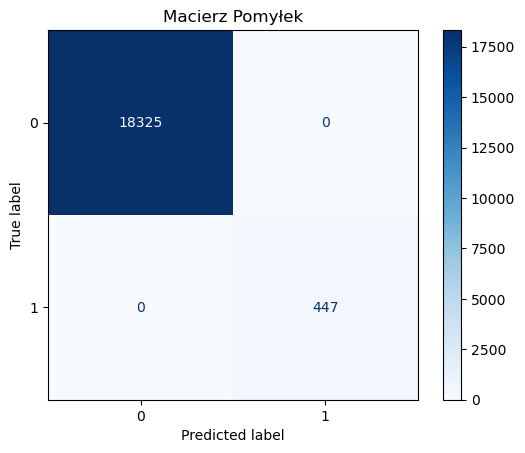

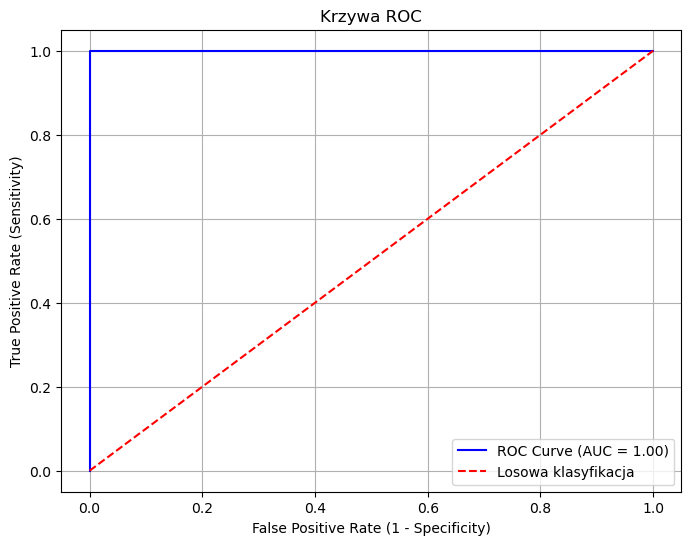

In [ ]:
best_rf = grid_search_neo.best_estimator_
y_pred_neo = best_rf.predict(X_neo_test)

print("neo")
accuracy, sensitivity, specificity = calculate_metrics(y_neo_test, y_pred_neo)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
plot_confusion_matrix(y_neo_test, y_pred_neo)
plot_roc_curve(y_neo_test, y_pred_neo)

### PHA

#### Próbkowanie

In [ ]:
pha_data = X
pha_data['pha'] = y_pha

pha_data = pha_data.sample(frac=0.1, random_state=my_index)

X_pha = pha_data.drop(columns=['pha'])
y_pha_new = pha_data['pha']

#### Podział na treningowe i testowe

In [ ]:
X_pha_train, X_pha_test, y_pha_train, y_pha_test = train_test_split(X_pha, y_pha_new, test_size=0.2, random_state=my_index)

print(X_pha_train.shape, y_pha_train.shape, X_pha_test.shape, y_pha_test.shape)

#### Optymalny podział hiperparametrów

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=my_index)
grid_search_pha = GridSearchCV(rf, param_grid, n_jobs=1)
grid_search_pha.fit(X_pha_train, y_pha_train)

print("Najlepsze parametry:", grid_search_pha.best_params_)

#### Wyniki dla pha

In [ ]:
best_rf = grid_search_pha.best_estimator_
y_pred_pha = best_rf.predict(X_pha_test)

print("pha")
accuracy, sensitivity, specificity = calculate_metrics(y_pha_test, y_pred_pha)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
plot_confusion_matrix(y_pha_test, y_pred_pha)
plot_roc_curve(y_pha_test, y_pred_pha)

#### Porównanie hiperparametrów Neo i Pha

In [ ]:
neo_params = grid_search_neo.best_params_
pha_params = grid_search_pha.best_params_

comparison_df = pd.DataFrame({
    'NEO': pd.Series(neo_params),
    'PHA': pd.Series(pha_params)
})

print(comparison_df)

## Zadanie na 5

Analiza wpływu wielkości lasu na jego skuteczność

#### Własna implementacja

In [ ]:
max_population = range(1, 41, 5)

accuracies = []
sensitivities = []
specificities = []
speed = []

for population in max_population:
    times = []
    accs = []
    sens = []
    spec = []
    for _ in range(5):
        clf = RandomForest(n_estimators=population)
        clf.fit(X_neo_train.to_numpy(), y_neo_train.to_numpy())
        start_time = time.time()
        y_pred = clf.predict(X_neo_test.to_numpy())
        elapsed = time.time() - start_time
        accuracy, sensitivity, specificity = calculate_metrics(y_neo_test, y_pred)
        accs.append(accuracy)
        sens.append(sensitivity)
        spec.append(specificity)
        times.append(elapsed)
    accuracies.append(np.mean(accs))
    sensitivities.append(np.mean(sens))
    specificities.append(np.mean(spec))
    speed.append(np.mean(times))

plt.figure(figsize=(12, 10))

for i, (vals, label, color) in enumerate(zip(
    [accuracies, sensitivities, specificities, speed],
    ['Accuracy', 'Sensitivity', 'Specificity', 'Czas [s]'],
    ['b', 'orange', 'green', 'red'])):
    plt.subplot(2, 2, i+1)
    plt.plot(max_population, vals, marker='o', color=color)
    plt.xlabel('Populacja')
    plt.ylabel(label)
    plt.title(f'{label} vs Max Depth')
    plt.grid(True)

plt.tight_layout()
plt.show()

#### Sklearn

In [ ]:
accuracies = []
sensitivities = []
specificities = []
speed = []

for population in max_population:
    times = []
    accs = []
    sens = []
    spec = []
    for _ in range(5):
        clf = RandomForestClassifier(n_estimators=population)
        clf.fit(X_neo_train, y_neo_train)
        start_time = time.time()
        y_pred = clf.predict(X_neo_test)
        elapsed = time.time() - start_time
        accuracy, sensitivity, specificity = calculate_metrics(y_neo_test, y_pred)
        accs.append(accuracy)
        sens.append(sensitivity)
        spec.append(specificity)
        times.append(elapsed)
    accuracies.append(np.mean(accs))
    sensitivities.append(np.mean(sens))
    specificities.append(np.mean(spec))
    speed.append(np.mean(times))

plt.figure(figsize=(12, 10))

for i, (vals, label, color) in enumerate(zip(
    [accuracies, sensitivities, specificities, speed],
    ['Accuracy', 'Sensitivity', 'Specificity', 'Czas [s]'],
    ['b', 'orange', 'green', 'red'])):
    plt.subplot(2, 2, i+1)
    plt.plot(max_population, vals, marker='o', color=color)
    plt.xlabel('Populacja')
    plt.ylabel(label)
    plt.title(f'{label} vs Max Depth')
    plt.grid(True)

plt.tight_layout()
plt.show()